In [83]:
try:
    from lerobot.datasets.lerobot_dataset import LeRobotDataset
    _LEROBOT_VERSION = '2.1'
except:
    from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
    _LEROBOT_VERSION = '2.0'

repo_id = 'Koorye/pika'

if _LEROBOT_VERSION == '2.1':
    dataset = LeRobotDataset(repo_id=repo_id, video_backend='pyav')
else:
    dataset = LeRobotDataset(repo_id=repo_id, local_files_only=True)

iterator = iter(dataset)

dict_keys(['third_base_rgb', 'left_wrist_base_rgb', 'left_wrist_fisheye_rgb', 'right_wrist_base_rgb', 'right_wrist_fisheye_rgb', 'states', 'actions', 'third_base_depth', 'left_wrist_base_depth', 'right_wrist_base_depth', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])
tensor(0)
tensor(0)
tensor([-0.0370,  0.0505, -0.1803,  0.0195,  0.8931,  1.6720,  1.6900,  0.7116,
         0.1958, -0.1770, -0.0139,  0.8949,  1.6391,  1.6800])
torch.Size([3, 480, 640])


/home/agilex/miniconda3/envs/pi0-for-pika-wsh/lib/python3.11/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


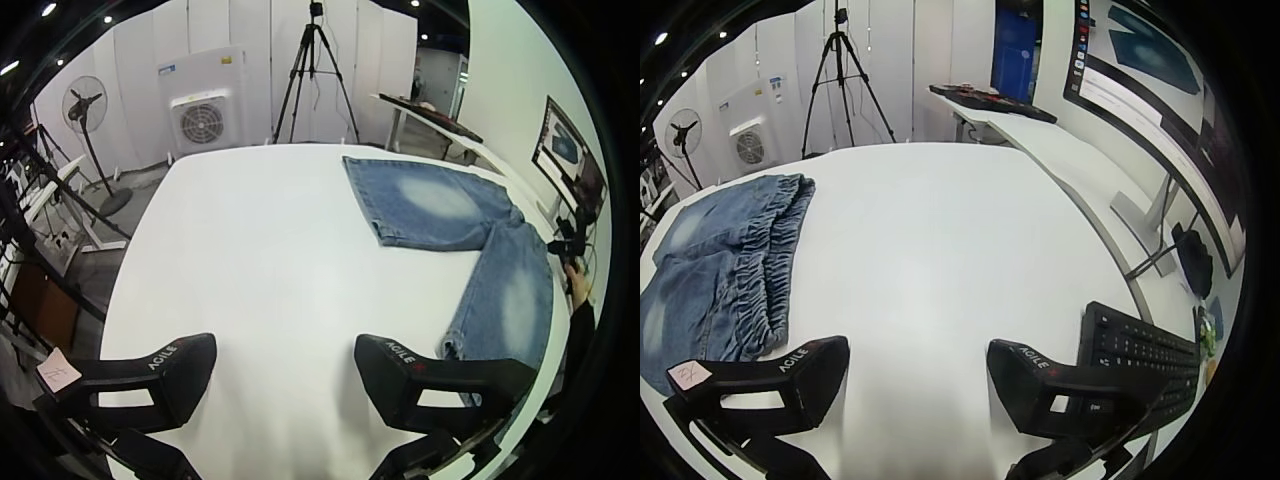

In [ ]:
import cv2
import numpy as np
from PIL import Image


def get_next_sample(iterator, k):
    sample = next(iterator)
    for _ in range(k - 1):
        sample = next(iterator)
    return sample

sample = get_next_sample(iterator, 10)
print(sample.keys())
print(sample['episode_index'])
print(sample['frame_index'])
print(sample['actions'])
print(sample['left_wrist_fisheye_rgb'].shape)
Image.fromarray(cv2.hconcat([
    np.uint8(sample['left_wrist_fisheye_rgb'].permute(1, 2, 0).numpy() * 255), 
    np.uint8(sample['right_wrist_fisheye_rgb'].permute(1, 2, 0).numpy() * 255),
]))

In [52]:
import numpy as np

iterator = iter(dataset)
past_sample = next(iterator)
current_episode = past_sample['episode_index'].item()

delta_actions_list = []

while True:
    sample = get_next_sample(iterator, 1)
    if sample['frame_index'].item() > 300:
        break
    delta_actions = sample['actions'] - past_sample['actions']
    delta_actions[6] = sample['actions'][6]
    delta_actions[13] = sample['actions'][13]
    print(delta_actions)
    delta_actions_list.append(delta_actions.numpy())
    past_sample = sample

delta_actions_list = np.stack(delta_actions_list)
print(delta_actions_list.shape)
np.save('../examples/example_actions.npy', delta_actions_list)

tensor([ 4.0731e-04, -1.6050e-03, -3.3753e-04, -1.6706e-03,  8.2673e-03,
         7.0214e-05,  1.6900e+00,  7.3051e-04, -6.7721e-04,  5.8386e-04,
        -8.4569e-03, -2.4313e-03, -9.0778e-03,  1.6800e+00])
tensor([ 9.1165e-04, -1.1012e-03, -2.2128e-05, -3.3363e-03,  2.4886e-03,
        -3.6561e-03,  1.6900e+00,  2.4045e-04, -1.0006e-03,  7.1788e-04,
        -3.7598e-03, -1.1329e-03, -2.2788e-03,  1.6800e+00])
tensor([ 1.3205e-03, -1.0171e-03,  4.8797e-04, -6.3741e-03,  1.3691e-03,
        -6.8498e-03,  1.6900e+00, -7.2116e-04, -1.1754e-03,  2.0052e-03,
         8.2036e-04, -1.0056e-03,  3.0887e-03,  1.6800e+00])
tensor([ 2.0476e-03, -1.4694e-03,  9.9531e-04, -1.0743e-02, -3.2359e-04,
        -1.3215e-02,  1.6900e+00, -1.3997e-03, -1.5535e-03,  3.8145e-03,
         2.5328e-03, -3.3797e-03,  5.5987e-03,  1.6800e+00])
tensor([ 2.3899e-03, -1.1484e-03,  1.6856e-03, -1.1344e-02, -6.5945e-03,
        -1.4414e-02,  1.6900e+00, -1.2296e-03, -1.2055e-03,  4.2973e-03,
         6.5161e-04, -8.08

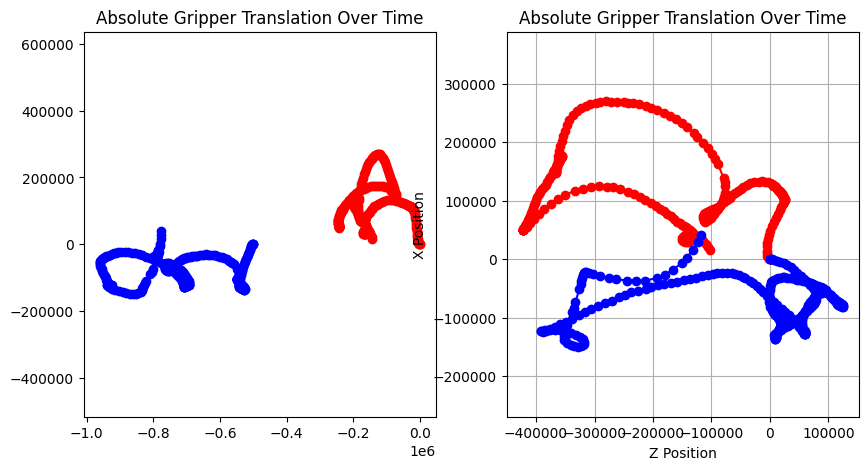

In [163]:
import math
import numpy as np


def delta_to_absolute_root_translation(delta, state, delta_with_grip=False):
    """
    Transform delta to absolute root translation,
    delta and state are in the same coordinate system.
    Params:
    - delta: [x, y, z, rx, ry, rz, grip] in world frame, x, y, z unit 0.001mm and rx, ry, rz unit 0.001 degree
    - state: [x, y, z, rx, ry, rz, grip] in world frame, x, y, z unit 0.001mm and rx, ry, rz unit 0.001 degree
    """
    pose6d = delta[:6] + state[:6]
    grip = delta[6]
    if delta_with_grip:
        grip += state[6]
    return np.concatenate([pose6d, [grip]])


def deg001_to_rad(deg001):
    """Convert 0.001 degrees to radians"""
    return deg001 * (math.pi / (180 * 1000))

def rad_to_deg001(rad):
    """Convert radians to 0.001 degrees"""
    return rad * (180 * 1000) / math.pi

def euler_to_rotation_matrix(rx, ry, rz):
    """Convert Euler angles (in radians) to rotation matrix (XYZ order)"""
    # XYZ order: first rx (roll), then ry (pitch), then rz (yaw)
    cx, sx = math.cos(rx), math.sin(rx)
    cy, sy = math.cos(ry), math.sin(ry)
    cz, sz = math.cos(rz), math.sin(rz)
    
    # Rotation matrix for XYZ order
    R = np.array([
        [cy*cz, sx*sy*cz - cx*sz, cx*sy*cz + sx*sz],
        [cy*sz, sx*sy*sz + cx*cz, cx*sy*sz - sx*cz],
        [-sy,   sx*cy,            cx*cy]
    ])
    return R

def delta_to_absolute_gripper_translation(delta, state, delta_with_grip=False):
    """
    Transform delta to absolute gripper translation,
    delta is in gripper frame and state is in world frame.
    
    Params:
    - delta: [x, y, z, rx, ry, rz, grip] in gripper frame (x=forward, z=up)
             units: x,y,z in 0.001mm, rx,ry,rz in 0.001 degree
    - state: [x, y, z, rx, ry, rz, grip] in world frame (z=up, x=forward)
             units: x,y,z in 0.001mm, rx,ry,rz in 0.001 degree
    
    Returns:
    - Absolute position and orientation in world frame [x, y, z, rx, ry, rz, grip]
    """
    # Extract state components
    state_pos = np.array(state[:3])  # [x, y, z]
    state_rot = np.array(state[3:6])  # [rx, ry, rz]
    state_grip = state[6]  # Gripper position
    
    # Extract delta components
    delta_pos = np.array(delta[:3])  # [x, y, z]
    delta_rot = np.array(delta[3:6])  # [rx, ry, rz]
    delta_grip = delta[6]  # Gripper position
    
    # Convert angles from 0.001 degrees to radians
    state_rot_rad = np.array([deg001_to_rad(a) for a in state_rot])
    delta_rot_rad = np.array([deg001_to_rad(a) for a in delta_rot])
    
    # Get rotation matrix for state (world to gripper frame)
    R_state = euler_to_rotation_matrix(*state_rot_rad)
    
    # Transform delta position from gripper frame to world frame
    # Note: Rotation matrix transforms vectors from gripper frame to world frame
    delta_pos_world = R_state @ delta_pos

    # Calculate absolute position
    abs_pos = state_pos + delta_pos_world
    
    # Calculate absolute rotation
    # Get rotation matrix for delta (gripper frame)
    R_delta = euler_to_rotation_matrix(*delta_rot_rad)
    
    # Combined rotation: R_total = R_state * R_delta
    R_total = R_state @ R_delta
    
    # Convert combined rotation matrix back to Euler angles (XYZ order)
    # Calculate Euler angles from rotation matrix
    sy = math.sqrt(R_total[0, 0] ** 2 + R_total[1, 0] ** 2)
    singular = sy < 1e-6
    
    if not singular:
        rx = math.atan2(R_total[2,1], R_total[2,2])
        ry = math.atan2(-R_total[2,0], sy)
        rz = math.atan2(R_total[1,0], R_total[0,0])
    else:
        rx = math.atan2(-R_total[1,2], R_total[1,1])
        ry = math.atan2(-R_total[2,0], sy)
        rz = 0
    
    # Convert back to 0.001 degrees
    abs_rot = np.array([rx, ry, rz])
    abs_rot_deg001 = np.array([rad_to_deg001(a) for a in abs_rot])
    
    grip = delta_grip
    if delta_with_grip:
        grip += state_grip
    
    return np.concatenate([abs_pos, abs_rot_deg001, [grip]]).astype(np.int64)


def pika_to_piper(states):
    """
    Convert Pika states to Piper states.
    Params:
    - states: [x, y, z, rx, ry, rz, grip]
    x, y, z in meters
    rx, ry, rz in radians
    grip in [0, 1.6]
    Returns:
    - states: [x, y, z, rx, ry, rz, grip]
    x, y, z in 0.001mm
    rx, ry, rz in 0.001 degree
    grip in [0, 60000]
    """
    return np.array([
        int(states[0] * 1e6),  # x in 0.001mm
        int(states[1] * 1e6),  # y in 0.001mm
        int(states[2] * 1e6),  # z in 0.001mm
        int(states[3] * 1e5),  # rx in 0.001 degree
        int(states[4] * 1e5),  # ry in 0.001 degree
        int(states[5] * 1e5),  # rz in 0.001 degree
        int(states[6] / 1.6 * 60000)  # grip in [0, 60000]
    ])


import matplotlib.pyplot as plt

left_state = [0,        0, 0, 0, 60000, 0, 60000]
right_state = [0, -500000, 0, 0, 0, 0, 60000]
left_states_list = [left_state]
right_states_list = [right_state]

for action in delta_actions_list:
    left_action = pika_to_piper(action[:7])
    right_action = pika_to_piper(action[7:])
    left_state = delta_to_absolute_gripper_translation(left_action, left_state, delta_with_grip=False)
    right_state = delta_to_absolute_gripper_translation(right_action, right_state, delta_with_grip=False)
    left_states_list.append(left_state.copy())
    right_states_list.append(right_state.copy())

left_states_list = np.array(left_states_list)
right_states_list = np.array(right_states_list)

# # 3d scatter
# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(left_states_list[:, 0] / 1e6, left_states_list[:, 1] / 1e6, left_states_list[:, 2] / 1e6, c='b', label='Left Gripper')
# ax.scatter(right_states_list[:, 0] / 1e6, right_states_list[:, 1] / 1e6, right_states_list[:, 2] / 1e6, c='r', label='Right Gripper')
# ax.set_xlabel('X (m)')
# ax.set_ylabel('Y (m)')
# ax.set_zlabel('Z (m)')
# ax.set_title('Gripper Trajectories in 3D Space')
# plt.axis('equal')
# ax.legend()

plt.close()
plt.figure(figsize=(10, 5))

# 2d x y
plt.subplot(1, 2, 1)
plt.plot(left_states_list[:, 1], left_states_list[:, 0], marker='o', linestyle='-', color='r')
plt.plot(right_states_list[:, 1], right_states_list[:, 0], marker='o', linestyle='-', color='b')
plt.title('Absolute Gripper Translation Over Time')
# plt.xlabel('Y Position')
# plt.ylabel('X Position')
plt.axis('equal')
# plt.grid()

# 2d x z
plt.subplot(1, 2, 2)
plt.plot(left_states_list[:, 2], left_states_list[:, 0], marker='o', linestyle='-', color='r')
plt.plot(right_states_list[:, 2], right_states_list[:, 0], marker='o', linestyle='-', color='b')
plt.title('Absolute Gripper Translation Over Time')
plt.xlabel('Z Position')
plt.ylabel('X Position')
plt.axis('equal')
plt.grid()

plt.show()

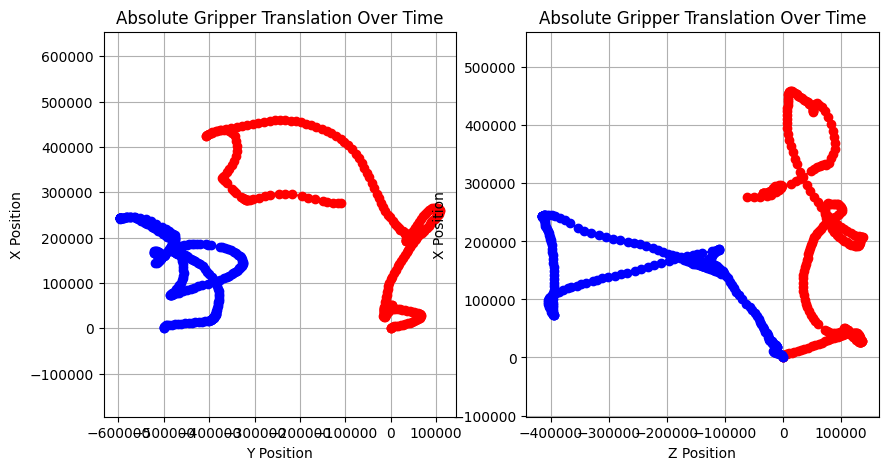

In [146]:
plt.close()
plt.figure(figsize=(10, 5))

# 2d x y
plt.subplot(1, 2, 1)
plt.plot(left_states_list[:, 1], left_states_list[:, 0], marker='o', linestyle='-', color='r')
plt.plot(right_states_list[:, 1], right_states_list[:, 0], marker='o', linestyle='-', color='b')
plt.title('Absolute Gripper Translation Over Time')
plt.xlabel('Y Position')
plt.ylabel('X Position')
plt.axis('equal')
plt.grid()

# 2d x z
plt.subplot(1, 2, 2)
plt.plot(left_states_list[:, 2], left_states_list[:, 0], marker='o', linestyle='-', color='r')
plt.plot(right_states_list[:, 2], right_states_list[:, 0], marker='o', linestyle='-', color='b')
plt.title('Absolute Gripper Translation Over Time')
plt.xlabel('Z Position')
plt.ylabel('X Position')
plt.axis('equal')
plt.grid()

plt.show()

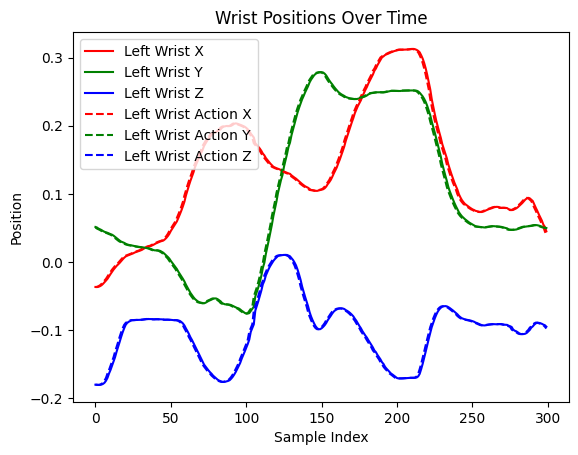

In [58]:
plt.plot(np.arange(len(left_states)), [state[0] for state in left_states], label='Left Wrist X', c='r')
plt.plot(np.arange(len(left_states)), [state[1] for state in left_states], label='Left Wrist Y', c='g')
plt.plot(np.arange(len(left_states)), [state[2] for state in left_states], label='Left Wrist Z', c='b')
plt.plot(np.arange(len(left_positions)), [action[0] for action in left_positions], label='Left Wrist Action X', c='r', linestyle='--')
plt.plot(np.arange(len(left_positions)), [action[1] for action in left_positions], label='Left Wrist Action Y', c='g', linestyle='--')
plt.plot(np.arange(len(left_positions)), [action[2] for action in left_positions], label='Left Wrist Action Z', c='b', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('Position')
plt.title('Wrist Positions Over Time')
plt.legend()
plt.show()

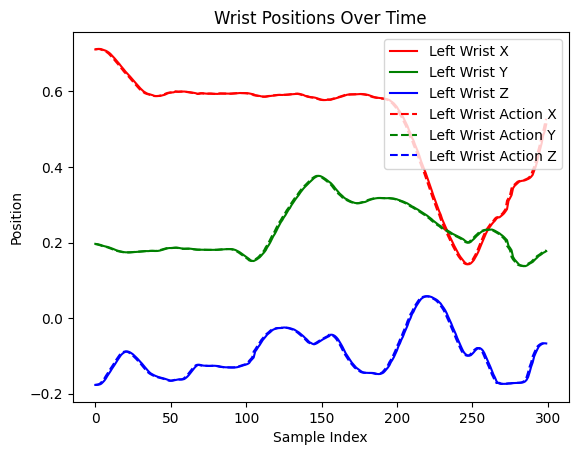

In [59]:
plt.plot(np.arange(len(left_states)), [state[0] for state in right_states], label='Left Wrist X', c='r')
plt.plot(np.arange(len(left_states)), [state[1] for state in right_states], label='Left Wrist Y', c='g')
plt.plot(np.arange(len(left_states)), [state[2] for state in right_states], label='Left Wrist Z', c='b')
plt.plot(np.arange(len(left_positions)), [action[0] for action in right_positions], label='Left Wrist Action X', c='r', linestyle='--')
plt.plot(np.arange(len(left_positions)), [action[1] for action in right_positions], label='Left Wrist Action Y', c='g', linestyle='--')
plt.plot(np.arange(len(left_positions)), [action[2] for action in right_positions], label='Left Wrist Action Z', c='b', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('Position')
plt.title('Wrist Positions Over Time')
plt.legend()
plt.show()

In [44]:
import numpy as np
import pandas as pd

df = pd.read_csv('poses.csv')
df = df.iloc[::5].reset_index(drop=True)
df = df.loc[1:].reset_index(drop=True) - df.loc[:len(df) - 2].reset_index(drop=True)
df['grip'] = 1.5
x = np.array(df)
x = np.concatenate([x, x], axis=-1)
np.save('../examples/example_actions.npy', x)